In [11]:
import pandas as pd # importing thelibraries
import numpy as np
url = "https://raw.githubusercontent.com/GeethaGunasekaran1/Dataset_rep/main/social_media_engagement_5000.csv"

df = pd.read_csv(url) # reading the file

df.head()
df.shape
df.columns


Index(['user_id', 'age', 'gender', 'country', 'post_id', 'post_type',
       'post_category', 'likes', 'comments', 'shares', 'watch_time_sec',
       'impression_count', 'posted_at', 'follower_count', 'is_verified',
       'device_type', 'sentiment', 'hashtags', 'engagement_rate'],
      dtype='object')

In [12]:


# 2. Check dataset
print(df.shape)
print(df.columns)
df.info()

# 3. Check missing values
print(df.isnull().sum())

# 4. Convert numerical columns
numeric_columns = [
    "age",
    "likes",
    "comments",
    "shares",
    "watch_time_sec",
    "impression_count",
    "follower_count",
    "engagement_rate"
]

for column in numeric_columns:
    df[column] = pd.to_numeric(df[column], errors="coerce")

# 5. Convert date column
df["posted_at"] = pd.to_datetime(
    df["posted_at"],
    format="%d-%m-%Y",
    errors="coerce"
)

# 6. Extract year and month
df["post_year"] = df["posted_at"].dt.year
df["post_month"] = df["posted_at"].dt.month

# 7. Convert engagement columns into NumPy array
engagement_array = df[["likes", "comments", "shares"]].dropna().to_numpy()

# 8. Calculate total engagement
total_engagement = np.sum(engagement_array, axis=1)

print("Average Likes:", np.mean(df["likes"]))
print("Maximum Likes:", np.max(df["likes"]))
print("Minimum Likes:", np.min(df["likes"]))
print("Total Likes:", np.sum(df["likes"]))

# Display result
df.head()

(5000, 19)
Index(['user_id', 'age', 'gender', 'country', 'post_id', 'post_type',
       'post_category', 'likes', 'comments', 'shares', 'watch_time_sec',
       'impression_count', 'posted_at', 'follower_count', 'is_verified',
       'device_type', 'sentiment', 'hashtags', 'engagement_rate'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   user_id           5000 non-null   int64  
 1   age               4850 non-null   float64
 2   gender            4850 non-null   object 
 3   country           5000 non-null   object 
 4   post_id           5000 non-null   int64  
 5   post_type         5000 non-null   object 
 6   post_category     5000 non-null   object 
 7   likes             4850 non-null   float64
 8   comments          4850 non-null   float64
 9   shares            4850 non-null   float64
 10  watch_ti

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,...,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate,post_year,post_month
0,25795,43.0,Female,Brazil,496713,image,fitness,7011.0,354.0,1157.0,...,44650,2022-12-17,81734,False,mobile,negative,#foodie #travel #love,0.190862,2022,12
1,10860,33.0,Male,Brazil,157326,reel,food,11750.0,2606.0,1807.0,...,80216,2023-06-02,5963,False,mobile,negative,#fitness,0.201493,2023,6
2,86820,32.0,Female,UK,109864,text,food,4862.0,344.0,955.0,...,44858,2023-05-07,501783,False,tablet,positive,#foodie,0.137345,2023,5
3,64886,51.0,Other,France,848877,text,fitness,5350.0,1083.0,1049.0,...,70455,2023-02-12,480212,False,mobile,negative,#music #foodie #fun,0.106195,2023,2
4,16265,34.0,Other,UK,449706,image,fitness,12682.0,2735.0,1300.0,...,6019,2023-05-23,383936,False,mobile,negative,#travel,2.777372,2023,5


In [13]:


#Detect Missing Values using isnull()

print("\nMissing Values using isnull():")
print(df.isnull().sum())



#  Detect Missing Values using isna()
print("\nMissing Values using isna():")
print(df.isna().sum())


# 7. Display only columns containing missing values


print("\nColumns containing missing values:")

missing_values = df.isnull().sum()

print(missing_values[missing_values > 0])



#  Create a copy for dropna demonstration


df_drop = df.copy()

# Remove rows containing any missing value
df_drop = df_drop.dropna()

print("\nShape after dropna():")
print(df_drop.shape)


# 8. Convert numerical columns to numeric


numeric_columns = [
    "age",
    "likes",
    "comments",
    "shares",
    "watch_time_sec",
    "impression_count",
    "follower_count",
    "engagement_rate"
]

for column in numeric_columns:
    df[column] = pd.to_numeric(df[column], errors="coerce")



# 9. Fill numerical missing values using MEDIAN


for column in numeric_columns:
    df[column] = df[column].fillna(df[column].median())



# 10. Categorical columns


categorical_columns = [
    "gender",
    "country",
    "post_type"
]


# 11. Fill categorical missing values using MODE


for column in categorical_columns:
    df[column] = df[column].fillna(df[column].mode()[0])

# 12. Forward Fill demonstration


df_ffill = df.copy()

df_ffill = df_ffill.ffill()

print("\nMissing values after Forward Fill:")
print(df_ffill.isnull().sum())


# 13. Backward Fill demonstration

df_bfill = df.copy()

df_bfill = df_bfill.bfill()

print("\nMissing values after Backward Fill:")
print(df_bfill.isnull().sum())



# 14. Final check after Median and Mode


print("\nFinal Missing Values:")
print(df.isnull().sum())



# 15. Display cleaned dataset


print("\nFirst 10 rows of cleaned dataset:")
print(df.head(10))


Missing Values using isnull():
user_id               0
age                 150
gender              150
country               0
post_id               0
post_type             0
post_category         0
likes               150
comments            150
shares              150
watch_time_sec        0
impression_count      0
posted_at             0
follower_count        0
is_verified           0
device_type           0
sentiment           150
hashtags              0
engagement_rate       0
post_year             0
post_month            0
dtype: int64

Missing Values using isna():
user_id               0
age                 150
gender              150
country               0
post_id               0
post_type             0
post_category         0
likes               150
comments            150
shares              150
watch_time_sec        0
impression_count      0
posted_at             0
follower_count        0
is_verified           0
device_type           0
sentiment           150
hashtags     

In [14]:
# Duplicate Handling

print("Number of duplicate rows:")
print(df.duplicated().sum())

df = df.drop_duplicates()

print("Duplicates after removal:")
print(df.duplicated().sum())


# Data Formatting

print("Data types before correction:")
print(df.dtypes)

numeric_columns = [
    "age",
    "likes",
    "comments",
    "shares",
    "watch_time_sec",
    "impression_count",
    "follower_count",
    "engagement_rate"
]

for column in numeric_columns:
    df[column] = pd.to_numeric(df[column], errors="coerce")

df["posted_at"] = pd.to_datetime(
    df["posted_at"],
    format="%d-%m-%Y",
    errors="coerce"
)

print("Data types after correction:")
print(df.dtypes)


# Standardize Gender

print("Gender categories before standardization:")
print(df["gender"].unique())

df["gender"] = df["gender"].str.strip()
df["gender"] = df["gender"].str.lower()

df["gender"] = df["gender"].replace({
    "m": "Male",
    "male": "Male",
    "man": "Male",
    "f": "Female",
    "female": "Female",
    "woman": "Female",
    "other": "Other",
    "non-binary": "Other",
    "nonbinary": "Other"
})

print("Gender categories after standardization:")
print(df["gender"].unique())


# Standardize Post Type

print("Post type categories before standardization:")
print(df["post_type"].unique())

df["post_type"] = df["post_type"].str.strip()
df["post_type"] = df["post_type"].str.lower()
df["post_type"] = df["post_type"].str.title()

print("Post type categories after standardization:")
print(df["post_type"].unique())


# Correct Unrealistic Values

print("Likes range:")
print(df["likes"].min(), df["likes"].max())

print("Comments range:")
print(df["comments"].min(), df["comments"].max())

print("Shares range:")
print(df["shares"].min(), df["shares"].max())

df.loc[df["likes"] < 0, "likes"] = np.nan
df.loc[df["comments"] < 0, "comments"] = np.nan
df.loc[df["shares"] < 0, "shares"] = np.nan

df["likes"] = df["likes"].fillna(df["likes"].median())
df["comments"] = df["comments"].fillna(df["comments"].median())
df["shares"] = df["shares"].fillna(df["shares"].median())

print("Negative likes:", (df["likes"] < 0).sum())
print("Negative comments:", (df["comments"] < 0).sum())
print("Negative shares:", (df["shares"] < 0).sum())


# Extract Hashtag Count

print("Columns in dataset:")
print(df.columns)

if "hashtags" in df.columns:
    df["hashtag_count"] = df["hashtags"].fillna("").apply(
        lambda x: str(x).count("#")
    )

elif "caption" in df.columns:
    df["hashtag_count"] = df["caption"].fillna("").apply(
        lambda x: str(x).count("#")
    )

else:
    print("No hashtags or caption column found.")


# Clean Sentiment Labels

if "sentiment" in df.columns:

    print("Sentiment categories before cleaning:")
    print(df["sentiment"].unique())

    df["sentiment"] = df["sentiment"].str.strip()
    df["sentiment"] = df["sentiment"].str.lower()

    df["sentiment"] = df["sentiment"].replace({
        "positive": "Positive",
        "pos": "Positive",
        "negative": "Negative",
        "neg": "Negative",
        "neutral": "Neutral",
        "neu": "Neutral"
    })

    print("Sentiment categories after cleaning:")
    print(df["sentiment"].unique())

else:
    print("No sentiment column found.")


# Final Check

print("Final dataset shape:")
print(df.shape)

print("Final data types:")
print(df.dtypes)

print("Final duplicate count:")
print(df.duplicated().sum())

print("Final missing values:")
print(df.isnull().sum())

print("First 10 rows:")
print(df.head(10))

Number of duplicate rows:
0
Duplicates after removal:
0
Data types before correction:
user_id                      int64
age                        float64
gender                      object
country                     object
post_id                      int64
post_type                   object
post_category               object
likes                      float64
comments                   float64
shares                     float64
watch_time_sec               int64
impression_count             int64
posted_at           datetime64[ns]
follower_count               int64
is_verified                   bool
device_type                 object
sentiment                   object
hashtags                    object
engagement_rate            float64
post_year                    int32
post_month                   int32
dtype: object
Data types after correction:
user_id                      int64
age                        float64
gender                      object
country                     obj

In [15]:
print("First 5 rows:")
print(df.head())

print("\nLast 5 rows:")
print(df.tail())

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nDataset Information:")
df.info()

print("\nSummary Statistics:")
print(df.describe())

print("\nGender Counts:")
print(df["gender"].value_counts())

print("\nPost Type Counts:")
print(df["post_type"].value_counts())

print("\nCountry Counts:")
print(df["country"].value_counts())

print("\nSentiment Counts:")
print(df["sentiment"].value_counts())

print("\nUnique Gender Values:")
print(df["gender"].unique())

print("\nUnique Post Types:")
print(df["post_type"].unique())

print("\nUnique Countries:")
print(df["country"].unique())

print("\nUnique Sentiments:")
print(df["sentiment"].unique())

print("\nNumber of Unique Gender Values:")
print(df["gender"].nunique())

print("\nNumber of Unique Post Types:")
print(df["post_type"].nunique())

print("\nNumber of Unique Countries:")
print(df["country"].nunique())

print("\nNumber of Unique Sentiments:")
print(df["sentiment"].nunique())

numeric_columns = [
    "age",
    "likes",
    "comments",
    "shares",
    "watch_time_sec",
    "impression_count",
    "follower_count",
    "engagement_rate"
]

correlation_matrix = df[numeric_columns].corr()

print("\nCorrelation Matrix:")
print(correlation_matrix)

print("\nAverage Likes by Post Type:")
print(df.groupby("post_type")["likes"].mean())

print("\nAverage Comments by Post Type:")
print(df.groupby("post_type")["comments"].mean())

print("\nAverage Shares by Post Type:")
print(df.groupby("post_type")["shares"].mean())

print("\nTotal Impressions by Country:")
print(df.groupby("country")["impression_count"].sum())

print("\nAverage Engagement Rate by Country:")
print(df.groupby("country")["engagement_rate"].mean())

df["engagement_score"] = (
    df["likes"] +
    df["comments"] +
    df["shares"]
)

print("\nEngagement Score:")
print(df[["likes", "comments", "shares", "engagement_score"]].head())

df["log_likes"] = np.log1p(df["likes"])
df["log_comments"] = np.log1p(df["comments"])
df["log_shares"] = np.log1p(df["shares"])
df["log_impressions"] = np.log1p(df["impression_count"])

if "hashtags" in df.columns:
    df["hashtag_count"] = df["hashtags"].fillna("").apply(
        lambda x: str(x).count("#")
    )
elif "caption" in df.columns:
    df["hashtag_count"] = df["caption"].fillna("").apply(
        lambda x: str(x).count("#")
    )

post_type_summary = df.groupby("post_type").agg({
    "likes": "mean",
    "comments": "mean",
    "shares": "mean",
    "impression_count": "mean",
    "engagement_rate": "mean",
    "engagement_score": "mean"
})

print("\nPost Type Summary:")
print(post_type_summary)

country_summary = df.groupby("country").agg({
    "likes": "mean",
    "comments": "mean",
    "shares": "mean",
    "impression_count": "sum",
    "engagement_rate": "mean",
    "engagement_score": "mean"
})

print("\nCountry Summary:")
print(country_summary)

sentiment_summary = df.groupby("sentiment").agg({
    "likes": "mean",
    "comments": "mean",
    "shares": "mean",
    "impression_count": "mean",
    "engagement_rate": "mean",
    "engagement_score": "mean"
})

print("\nSentiment Summary:")
print(sentiment_summary)

post_type_avg = df.groupby("post_type", as_index=False)["likes"].mean()

post_type_avg = post_type_avg.rename(
    columns={"likes": "average_likes"}
)

df = df.merge(
    post_type_avg,
    on="post_type",
    how="left"
)

print("\nAfter Merge:")
print(df[["post_type", "likes", "average_likes"]].head())

stat_columns = [
    "likes",
    "comments",
    "shares",
    "watch_time_sec",
    "engagement_rate",
    "follower_count"
]

print("\nMEAN:")

for column in stat_columns:
    print(column, ":", df[column].mean())

print("\nMEDIAN:")

for column in stat_columns:
    print(column, ":", df[column].median())

print("\nMODE:")

for column in stat_columns:
    print(column, ":", df[column].mode()[0])

print("\nSTANDARD DEVIATION:")

for column in stat_columns:
    print(column, ":", df[column].std())

print("\nVARIANCE:")

for column in stat_columns:
    print(column, ":", df[column].var())

print("\nPERCENTILES:")

for column in stat_columns:
    print("\n", column)
    print("25th Percentile:", df[column].quantile(0.25))
    print("50th Percentile:", df[column].quantile(0.50))
    print("75th Percentile:", df[column].quantile(0.75))
    print("90th Percentile:", df[column].quantile(0.90))

print("\nSKEWNESS:")

for column in stat_columns:
    print(column, ":", df[column].skew())

print("\nKURTOSIS:")

for column in stat_columns:
    print(column, ":", df[column].kurt())

statistics = pd.DataFrame({
    "Mean": df[stat_columns].mean(),
    "Median": df[stat_columns].median(),
    "Mode": df[stat_columns].mode().iloc[0],
    "Standard Deviation": df[stat_columns].std(),
    "Variance": df[stat_columns].var(),
    "25th Percentile": df[stat_columns].quantile(0.25),
    "50th Percentile": df[stat_columns].quantile(0.50),
    "75th Percentile": df[stat_columns].quantile(0.75),
    "90th Percentile": df[stat_columns].quantile(0.90),
    "Skewness": df[stat_columns].skew(),
    "Kurtosis": df[stat_columns].kurt()
})

print("\nComplete Statistical Summary:")
print(statistics)

First 5 rows:
   user_id   age  gender country  post_id post_type post_category    likes  \
0    25795  43.0  Female  Brazil   496713     Image       fitness   7011.0   
1    10860  33.0    Male  Brazil   157326      Reel          food  11750.0   
2    86820  32.0  Female      UK   109864      Text          food   4862.0   
3    64886  51.0   Other  France   848877      Text       fitness   5350.0   
4    16265  34.0   Other      UK   449706     Image       fitness  12682.0   

   comments  shares  ...  posted_at  follower_count is_verified  device_type  \
0     354.0  1157.0  ... 2022-12-17           81734       False       mobile   
1    2606.0  1807.0  ... 2023-06-02            5963       False       mobile   
2     344.0   955.0  ... 2023-05-07          501783       False       tablet   
3    1083.0  1049.0  ... 2023-02-12          480212       False       mobile   
4    2735.0  1300.0  ... 2023-05-23          383936       False       mobile   

   sentiment               hashtags 

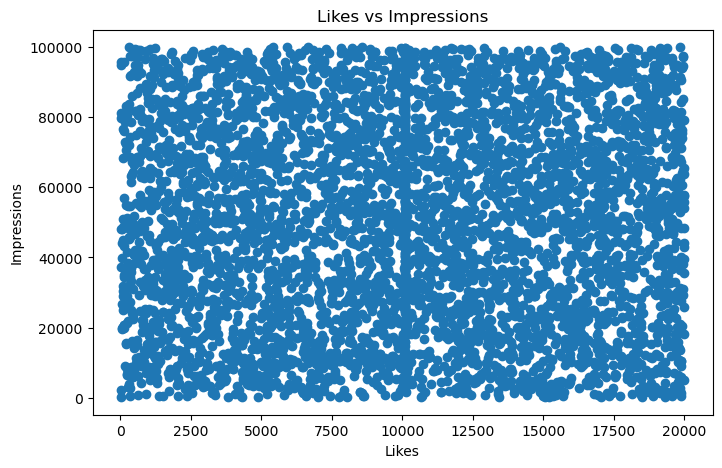

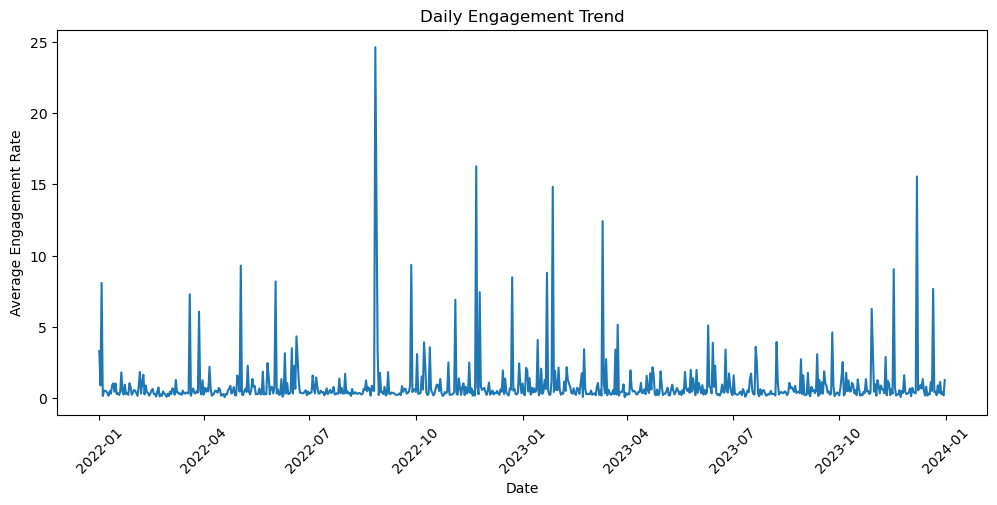

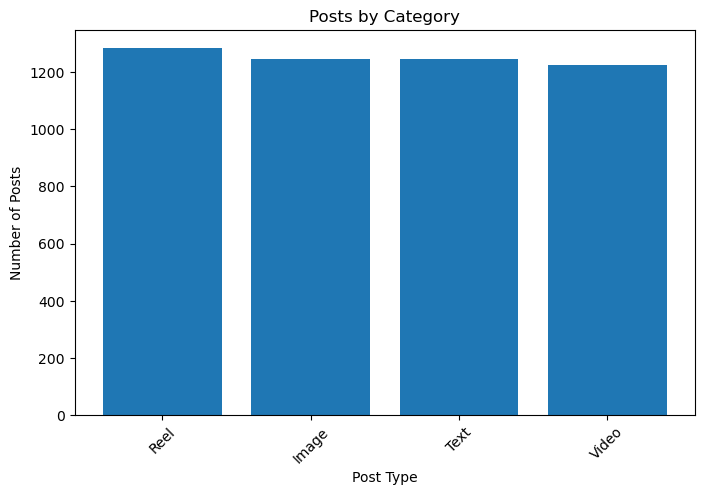

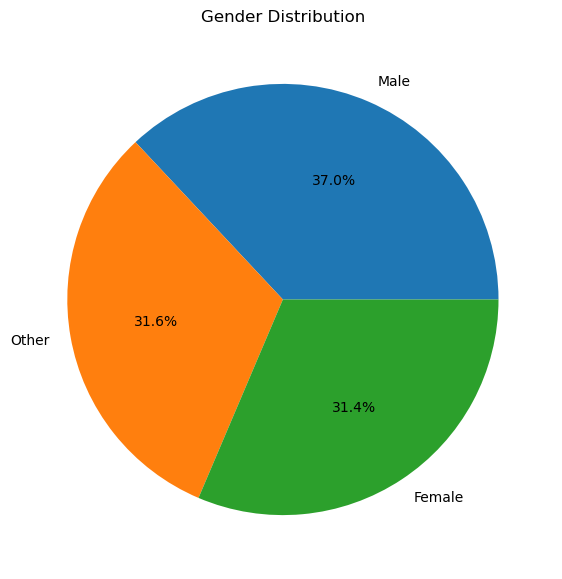

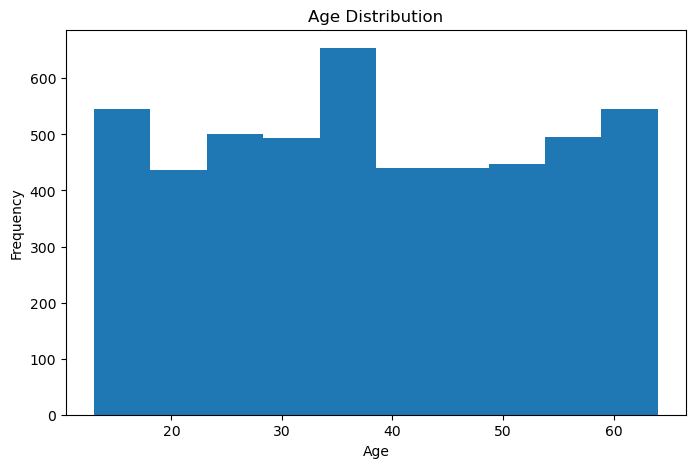

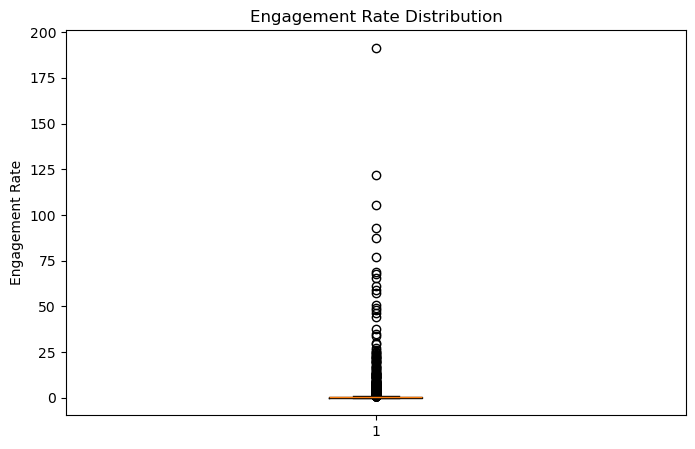

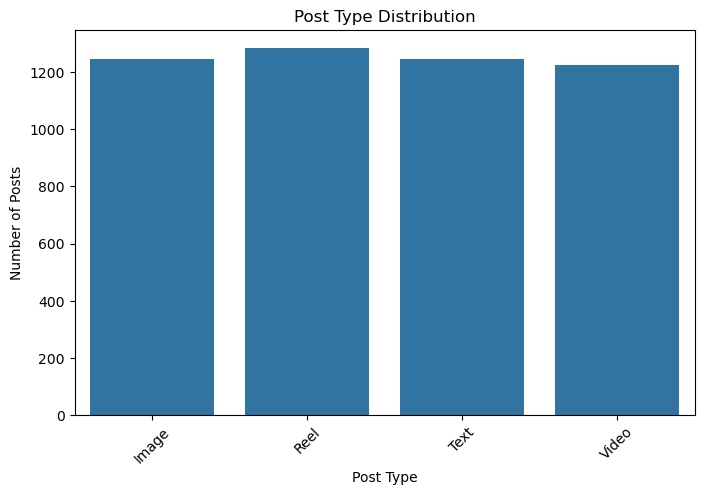

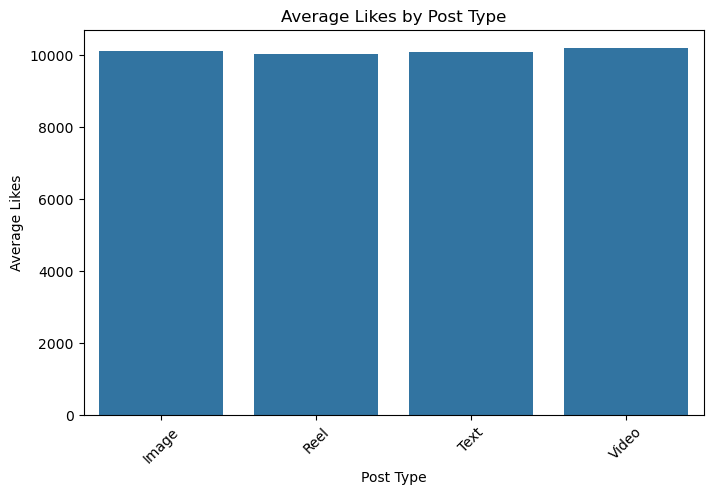

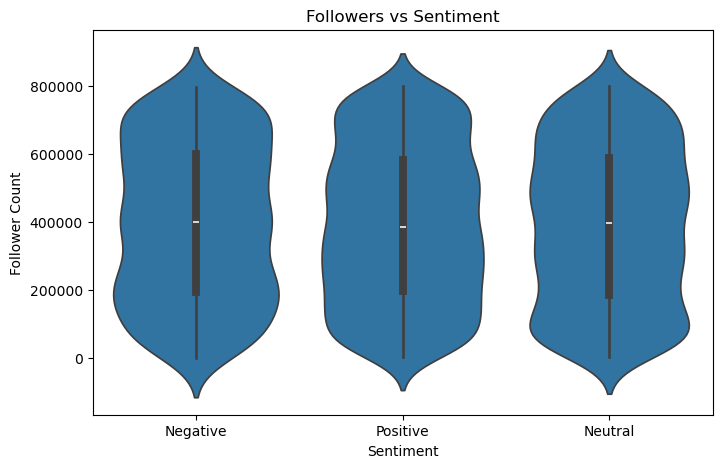

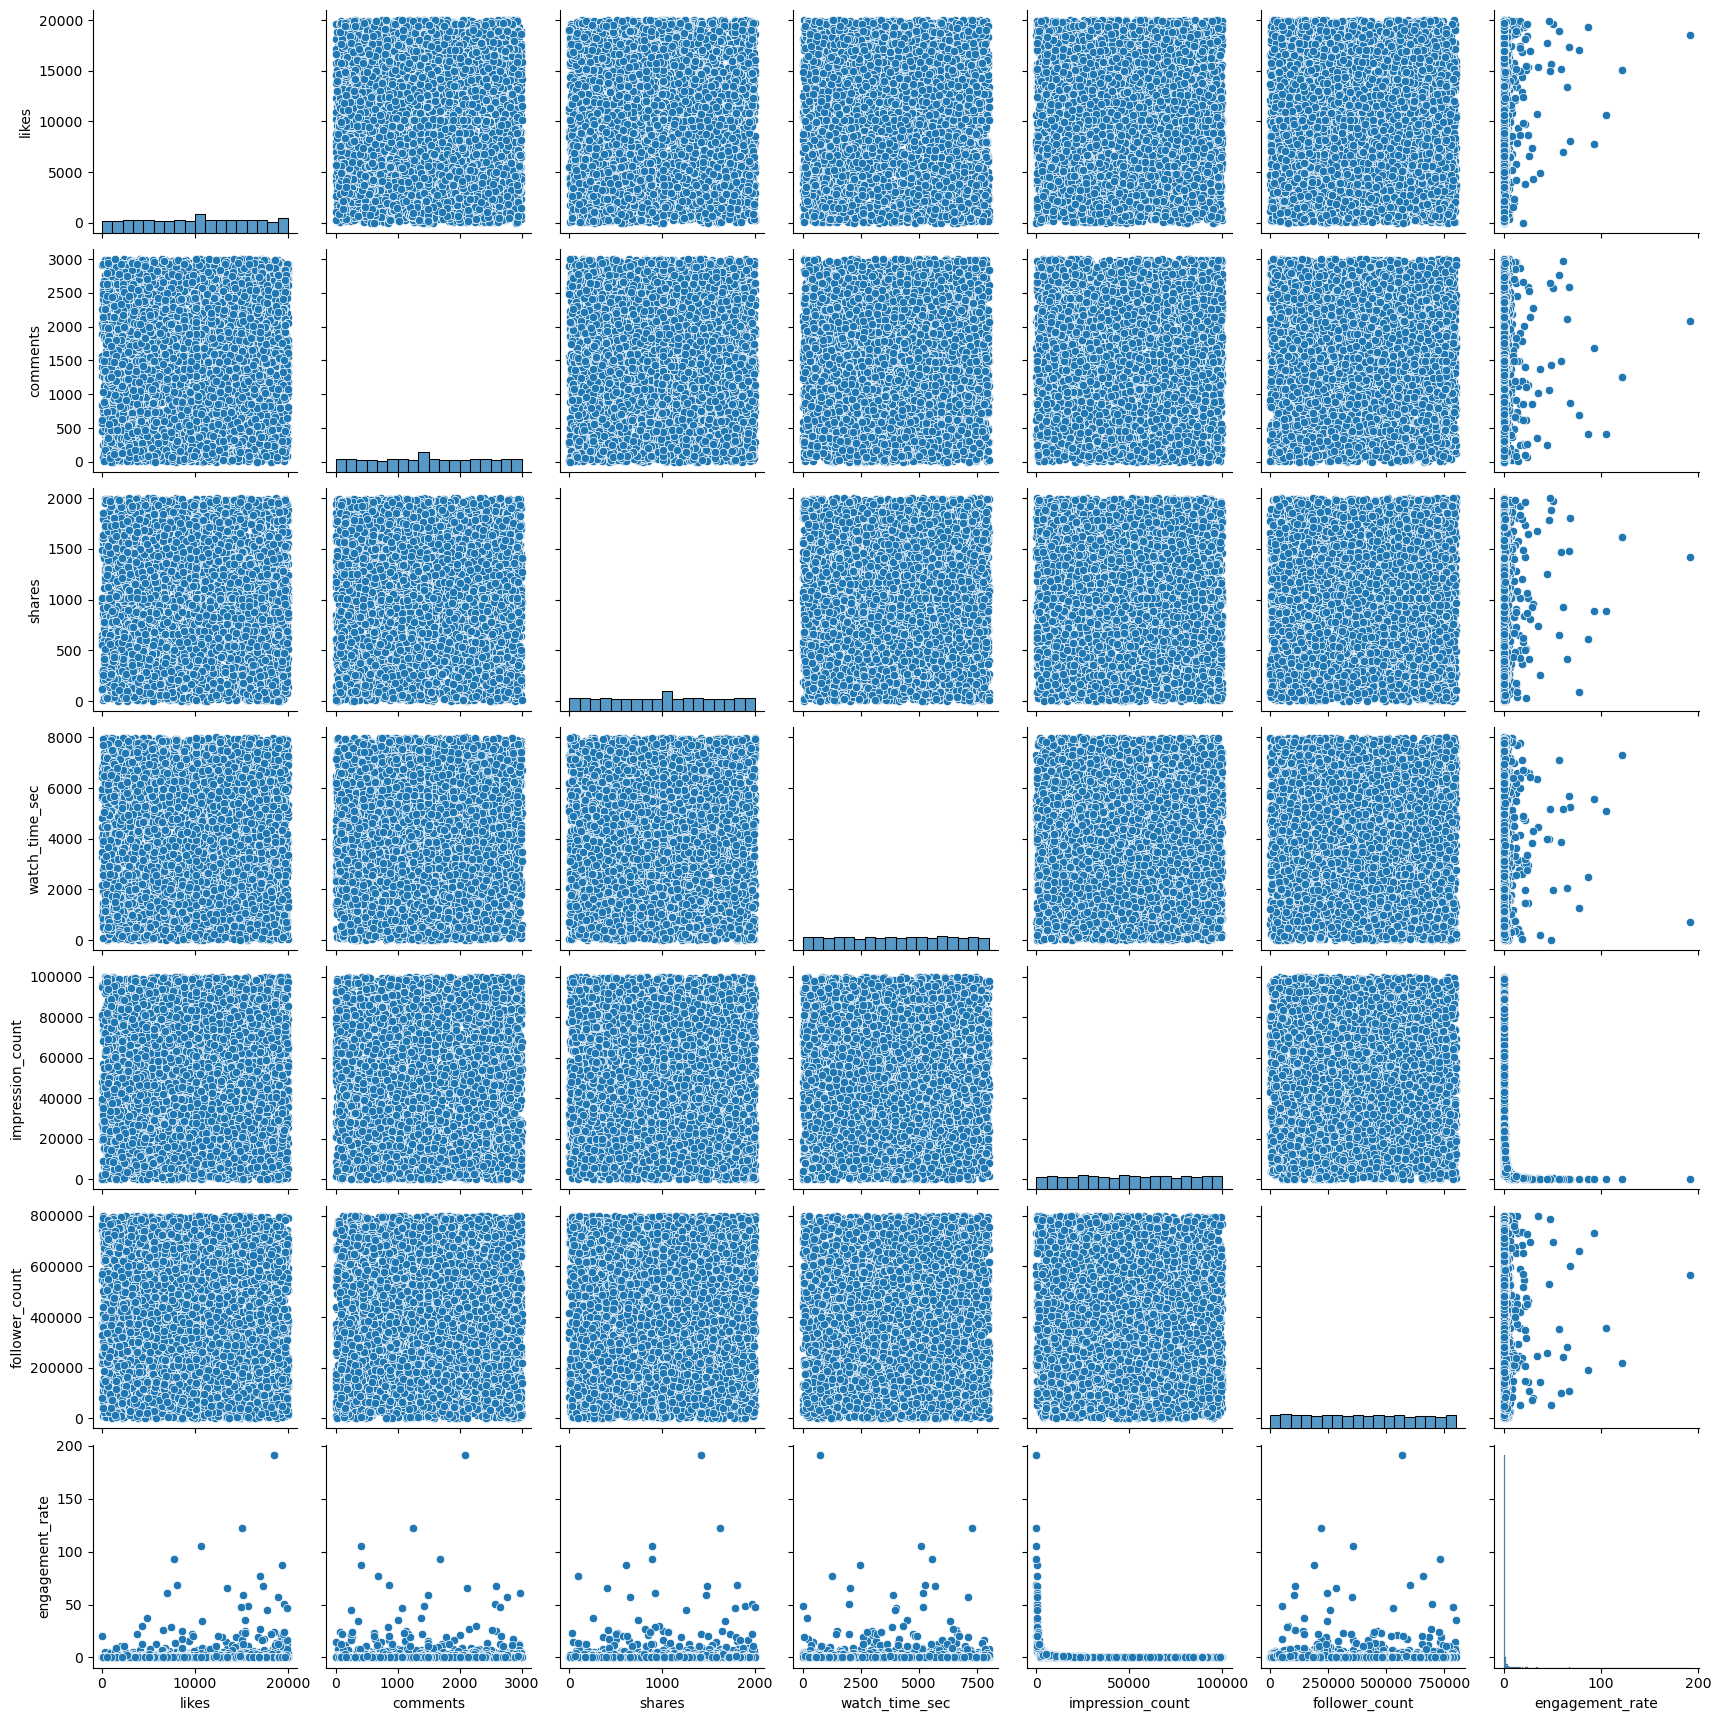

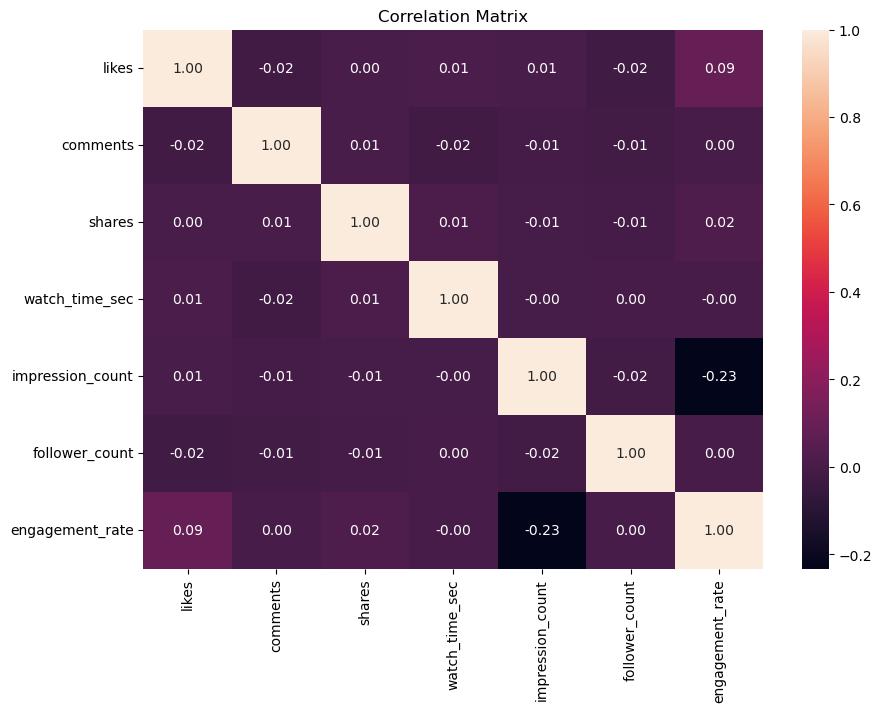

C:\Users\HP\anaconda3\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 94.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

plt.figure(figsize=(8, 5))
plt.scatter(df["likes"], df["impression_count"])
plt.xlabel("Likes")
plt.ylabel("Impressions")
plt.title("Likes vs Impressions")
plt.show()

daily_engagement = df.groupby("posted_at")["engagement_rate"].mean()

plt.figure(figsize=(12, 5))
plt.plot(daily_engagement.index, daily_engagement.values)
plt.xlabel("Date")
plt.ylabel("Average Engagement Rate")
plt.title("Daily Engagement Trend")
plt.xticks(rotation=45)
plt.show()

post_counts = df["post_type"].value_counts()

plt.figure(figsize=(8, 5))
plt.bar(post_counts.index, post_counts.values)
plt.xlabel("Post Type")
plt.ylabel("Number of Posts")
plt.title("Posts by Category")
plt.xticks(rotation=45)
plt.show()

gender_counts = df["gender"].value_counts()

plt.figure(figsize=(7, 7))
plt.pie(
    gender_counts.values,
    labels=gender_counts.index,
    autopct="%1.1f%%"
)
plt.title("Gender Distribution")
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(df["age"], bins=10)
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Age Distribution")
plt.show()

plt.figure(figsize=(8, 5))
plt.boxplot(df["engagement_rate"].dropna())
plt.ylabel("Engagement Rate")
plt.title("Engagement Rate Distribution")
plt.show()

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="post_type")
plt.xlabel("Post Type")
plt.ylabel("Number of Posts")
plt.title("Post Type Distribution")
plt.xticks(rotation=45)
plt.show()

avg_likes = df.groupby("post_type", as_index=False)["likes"].mean()

plt.figure(figsize=(8, 5))
sns.barplot(data=avg_likes, x="post_type", y="likes")
plt.xlabel("Post Type")
plt.ylabel("Average Likes")
plt.title("Average Likes by Post Type")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(8, 5))
sns.violinplot(
    data=df,
    x="sentiment",
    y="follower_count"
)
plt.xlabel("Sentiment")
plt.ylabel("Follower Count")
plt.title("Followers vs Sentiment")
plt.show()

numeric_features = [
    "likes",
    "comments",
    "shares",
    "watch_time_sec",
    "impression_count",
    "follower_count",
    "engagement_rate"
]

sns.pairplot(df[numeric_features])
plt.show()

correlation_matrix = df[numeric_features].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f"
)
plt.title("Correlation Matrix")
plt.show()

plt.figure(figsize=(8, 5))
sns.swarmplot(
    data=df,
    x="device_type",
    y="engagement_rate"
)
plt.xlabel("device_type")
plt.ylabel("Engagement Rate")
plt.title("Engagement Rate vs Device")
plt.show()

daily_engagement_plot = daily_engagement.reset_index()

fig = px.line(
    daily_engagement_plot,
    x="posted_at",
    y="engagement_rate",
    title="Interactive Daily Engagement Trend"
)
fig.show()

post_counts_plot = post_counts.reset_index()

post_counts_plot.columns = [
    "post_type",
    "count"
]

fig = px.bar(
    post_counts_plot,
    x="post_type",
    y="count",
    title="Interactive Posts by Category"
)
fig.show()

fig = px.scatter(
    df,
    x="likes",
    y="impression_count",
    size="engagement_rate",
    color="post_type",
    hover_data=["country", "gender"],
    title="Interactive Likes vs Impressions"
)
fig.show()

fig = px.scatter(
    df,
    x="follower_count",
    y="engagement_rate",
    size="likes",
    color="sentiment",
    hover_data=["post_type", "country"],
    title="Interactive Followers vs Engagement"
)
fig.show()

# Final Insights

## Content Performance

### Which post types have the highest engagement?

The average engagement rate was compared across different post types. The post type with the highest average engagement rate represents the content format that receives the most interaction from users. This helps identify which type of content performs best.

### Best-performing content category

The performance of different content categories was analysed using likes, comments, shares, impressions, and engagement rate. The category with the highest engagement rate can be considered the best-performing content category. Higher likes, comments, and shares indicate stronger audience interaction.

### Which countries have the highest average engagement rate?

The average engagement rate was compared across different countries. Countries with higher average engagement rates have audiences that interact more actively with social media content. This analysis can help identify geographical locations with stronger audience engagement.

## User Trends

### How age affects engagement

The relationship between age and engagement rate was analysed using correlation and age groups. The analysis helps identify which age groups have the highest engagement. This can be useful for understanding the target audience and creating content suitable for different age groups.

### Performance difference for verified accounts

The engagement performance of verified and non-verified accounts was compared using likes, comments, shares, and engagement rate. This analysis helps determine whether verified accounts receive higher audience engagement compared with non-verified accounts.

## Overall Conclusion

The analysis shows that social media engagement varies based on content type, country, age group, and account verification status. Identifying the best-performing content categories and the most engaged user groups can help improve content strategy and increase audience interaction. Country-level analysis can also help target audiences in locations with higher engagement. Comparing verified and non-verified accounts provides additional insight into how account status may influence engagement performance.